In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
22/7

3.142857142857143

In [2]:
from pathlib import Path
from DataLoader import MyDataloader
from Engine import Engine
import pandas as pd
import matplotlib.pyplot as plt
import torch
import Architecture
import Information as info

In [3]:
data_path = Path(r"/mnt/Data1/Python_Projects/Kaggle/data/house_prices/train.csv")
# data_path_heart = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
train_percent = 0.7
val_percent = 0.15
test_percent = 0.15
batch_size = 512
seed = 42
dataloader = MyDataloader(file_path=data_path,
                          train_percent=train_percent, 
                          val_percent=val_percent, 
                          test_percent=test_percent, 
                          batch_size=batch_size, 
                          random_seed=seed)
train, val, test = dataloader.fit()

try:
    print(len(train), len(val), len(test))
except:
    print(len(train), len(val))

2 1 1


/mnt/Data1/Python_Projects/Kaggle/Project 2 - House Pricing/Neural_Network/NN/DataLoader.py:73: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Alley"].fillna(0, inplace=True)
/mnt/Data1/Python_Projects/Kaggle/Project 2 - House Pricing/Neural_Network/NN/DataLoader.py:74: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are se

In [4]:
a = dataloader.data
b = dataloader.raw_data
a

,SalePrice,LotArea,Street,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,208500.0,8450.0,1.0,7.0,5.0,2003.0,2003.0,196.0,4.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,181500.0,9600.0,1.0,6.0,8.0,1976.0,1976.0,0.0,3.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,223500.0,11250.0,1.0,7.0,5.0,2001.0,2002.0,162.0,4.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,140000.0,9550.0,1.0,7.0,5.0,1915.0,1970.0,0.0,3.0,3.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,250000.0,14260.0,1.0,8.0,5.0,2000.0,2000.0,350.0,4.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,175000.0,7917.0,1.0,6.0,5.0,1999.0,2000.0,0.0,3.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1456,210000.0,13175.0,1.0,6.0,6.0,1978.0,1988.0,119.0,3.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1457,266500.0,9042.0,1.0,7.0,9.0,1941.0,2006.0,0.0,5.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1458,142125.0,9717.0,1.0,5.0,6.0,1950.0,1996.0,0.0,3.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [5]:
b

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
# for learning_rate in range(1, 100):
    # learning_rate = learning_rate**2 * 0.0001
    # print(learning_rate)
features_n = len(info.features_dataloader)
target_n = len(info.target_dataloader)
hidden_n1 = 64
hidden_n2 = 32

torch.manual_seed(42)
model = Architecture.NN(features_n=features_n, output_n=target_n, hidden_n1=hidden_n1, hidden_n2=hidden_n2)
print(model.parameters)
EPOCHS = 700
loss_fn = torch.nn.L1Loss()
learning_rate = 0.0016

optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

engine = Engine(model=model, train_dataloader=train,
                val_dataloader=val,
                test_dataloader=test,
                random_seed=42)
model0_results = engine.train(loss_fn=loss_fn,
                            optimizer=optimizer,
                            epochs_num=EPOCHS,
                            resolution=50,
                            early_stop_patience=50)

<bound method Module.parameters of NN(
  (l_0): Linear(in_features=240, out_features=64, bias=True)
  (l_1): Linear(in_features=64, out_features=64, bias=True)
  (l_2): Linear(in_features=64, out_features=64, bias=True)
  (l_3): Linear(in_features=64, out_features=64, bias=True)
  (l_00): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)>


  0%|          | 0/700 [00:00<?, ?it/s]

Epoch 50 | train: Loss 99231.238281 Accuracy -1.5038 | validation: Loss 92249.765625 Accuracy -1.2148
Epoch 100 | train: Loss 34019.295898 Accuracy 0.4745 | validation: Loss 35978.554688 Accuracy 0.4925
Epoch 150 | train: Loss 26848.751953 Accuracy 0.6428 | validation: Loss 29293.876953 Accuracy 0.6729
Epoch 200 | train: Loss 23139.377930 Accuracy 0.7298 | validation: Loss 25196.822266 Accuracy 0.7694
Epoch 250 | train: Loss 20614.693359 Accuracy 0.7799 | validation: Loss 22059.941406 Accuracy 0.8263
Epoch 300 | train: Loss 18947.070312 Accuracy 0.8079 | validation: Loss 20388.435547 Accuracy 0.8562
Epoch 350 | train: Loss 17669.236328 Accuracy 0.8274 | validation: Loss 19026.630859 Accuracy 0.8765
Epoch 400 | train: Loss 16803.415527 Accuracy 0.8401 | validation: Loss 18191.021484 Accuracy 0.8876
Epoch 450 | train: Loss 15992.880371 Accuracy 0.8494 | validation: Loss 17588.542969 Accuracy 0.8945
Epoch 500 | train: Loss 15318.602051 Accuracy 0.8567 | validation: Loss 17323.806641 Accur

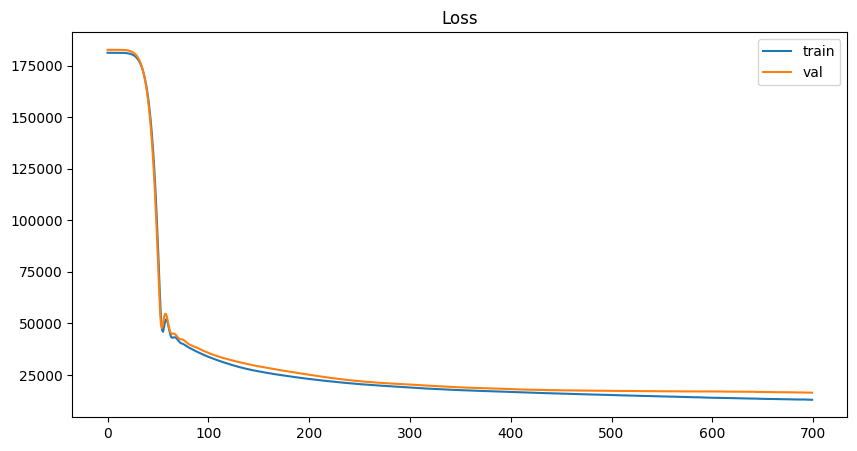

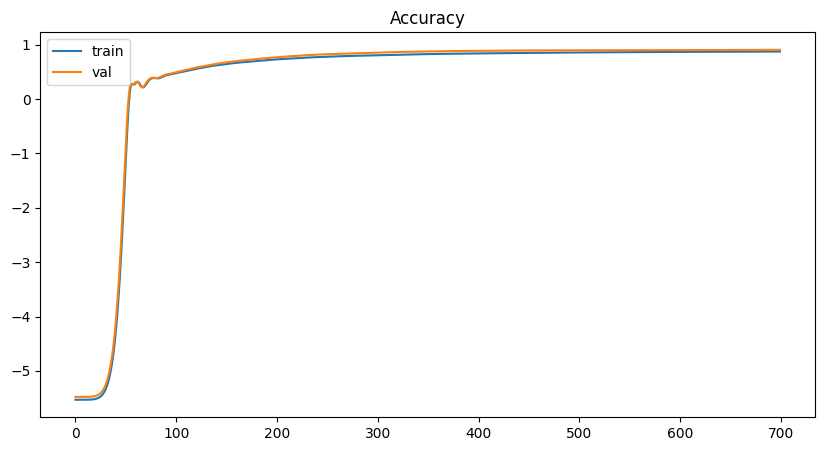

In [7]:
engine.plot_loss()
engine.plot_acc()


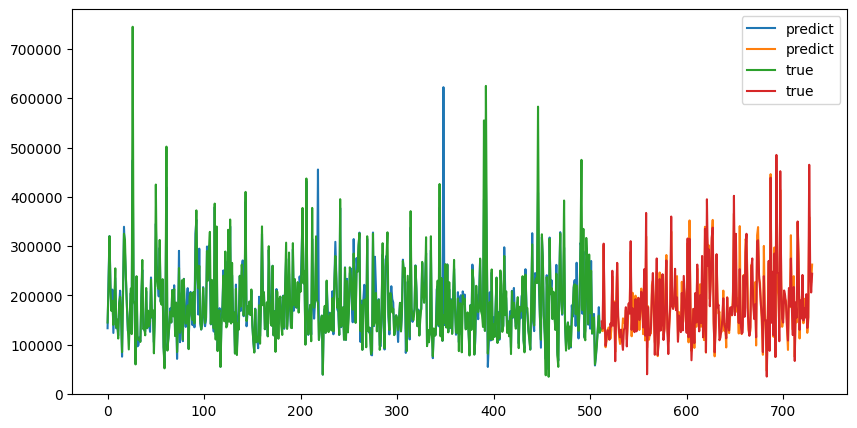

In [8]:
engine.plot_predict_real()

In [9]:
test_result = engine.test(loss_fn=loss_fn)

[!!!IMPORTANT NOTE!!!]
The test_function provided here is intended solely for the final model analysis and reporting purposes.
Please refrain from using it as a general-purpose function in your own projects. Always refer to
the appropriate train and validation data for developing and fine-tuning your own models.
Loss : 19728.345703125 and Accuracy : 0.8360605239868164


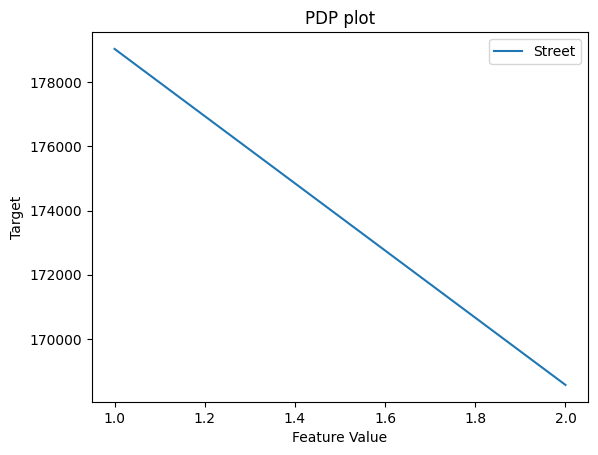

In [12]:
features1 = {"OverallQual": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}
features2 = {"YearRemodAdd": list(range(1950, 2011))}
features3 = {"GarageArea": sorted(list(dataloader.data["GarageArea"].unique()))}
features4 = {"Street": [1, 2]}

pdp_dataloader = dataloader.partial_dependence_plot_data(features=features4)
engine.partial_dependence_plot(pdp_data=pdp_dataloader)


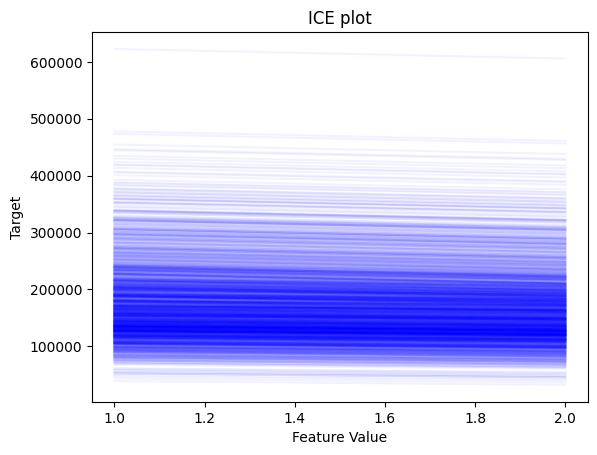

In [26]:
ice_dataloader = dataloader.individual_conditional_expectation_data(features=features4)
engine.individual_conditional_expectation(ice_data=dataloader.ice_data)

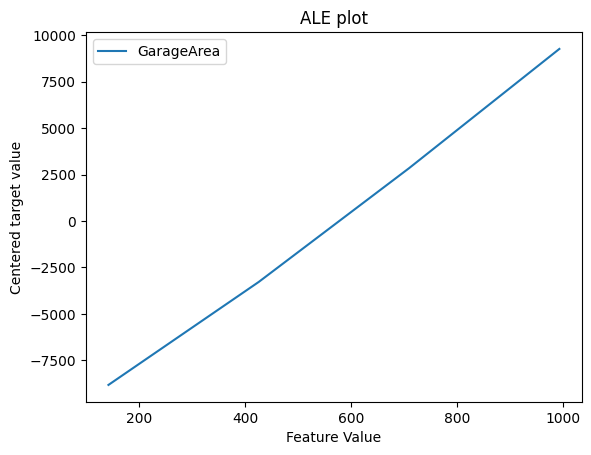

In [27]:
features = ["OverallQual", "YearRemodAdd", "GarageArea"]
ale_dataloader = dataloader.accumulated_local_effects_data(feature=features[2], n=5)
engine.accumulated_local_effects_plot(ale_dataloader)

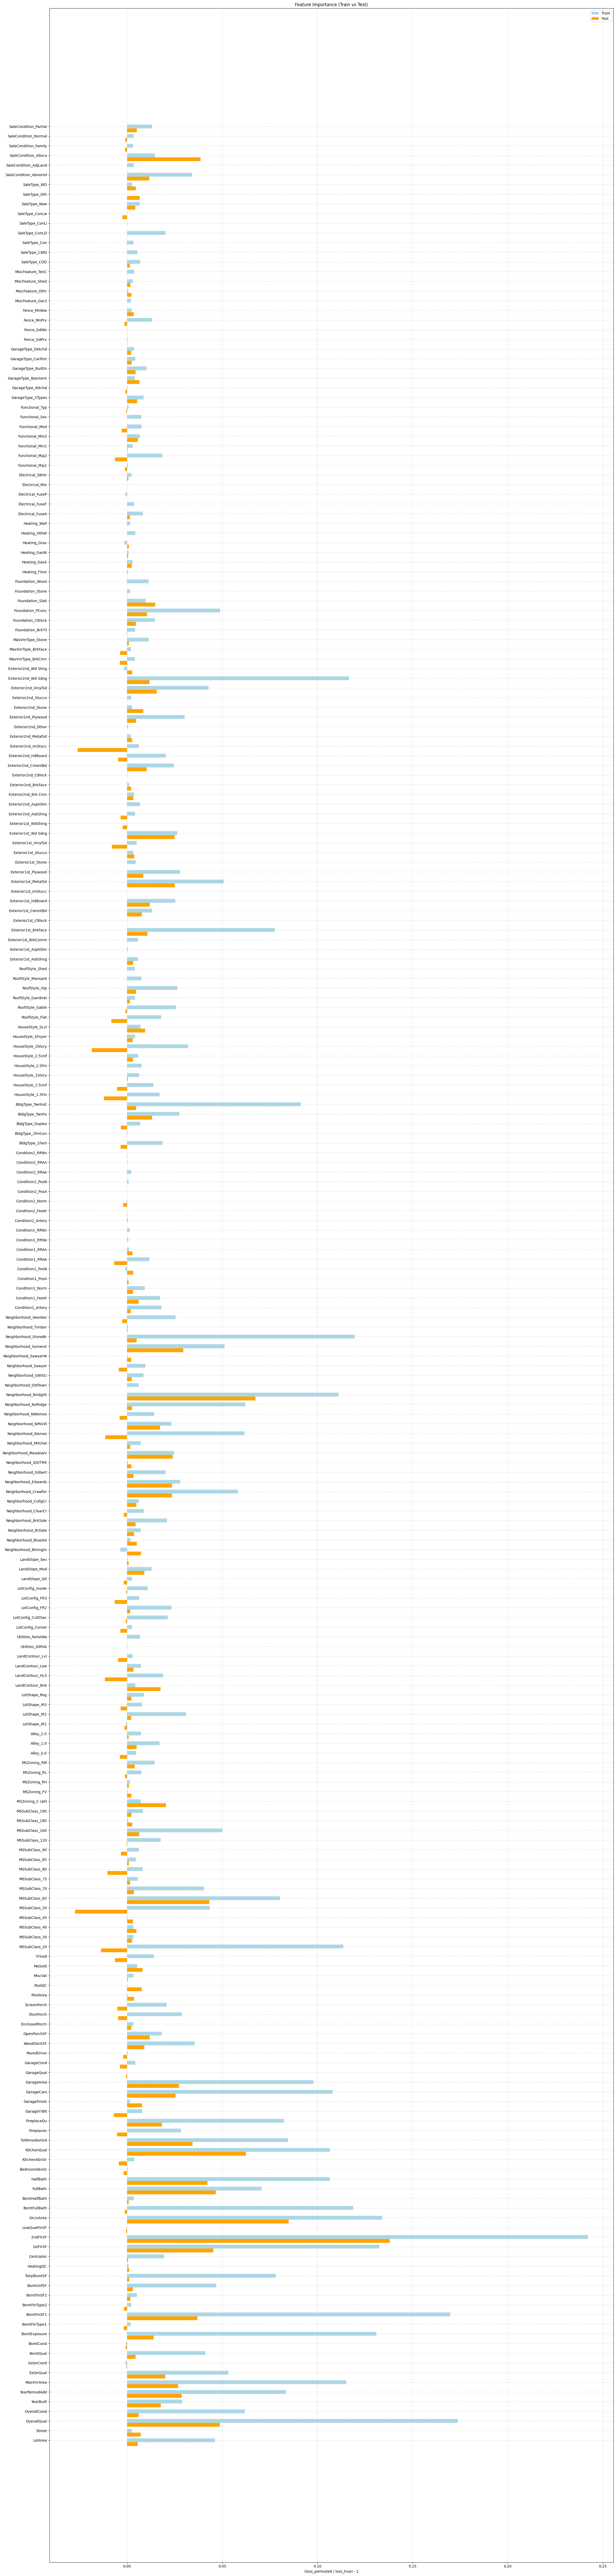

In [43]:
feature_importance_dataloader = dataloader.feature_importance_data(seed=42)
feature_loss = engine.feature_importance_plot(feature_importance_dataloader, loss_fn=loss_fn, fig_size=(24, 100))

In [11]:
features = {"OverallQual": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            "YearRemodAdd": list(range(1950, 2011))}

feature_intraction_data = dataloader.feature_intractionn_data(features=features)

<string>:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.11111111 0.11111111 0.11111111 ... 0.11111111 0.11111111 0.11111111]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.22222222 0.22222222 0.22222222 ... 0.22222222 0.22222222 0.22222222]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.33333333 0.33333333 0.33333333 ... 0.33333333 0.33333333 0.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Val

In [15]:
res = engine.feature_intraction_value(data=feature_intraction_data)

In [17]:
res["OverallQual|YearRemodAdd"]

[['1,1950',
  '1,1951',
  '1,1952',
  '1,1953',
  '1,1954',
  '1,1955',
  '1,1956',
  '1,1957',
  '1,1958',
  '1,1959',
  '1,1960',
  '1,1961',
  '1,1962',
  '1,1963',
  '1,1964',
  '1,1965',
  '1,1966',
  '1,1967',
  '1,1968',
  '1,1969',
  '1,1970',
  '1,1971',
  '1,1972',
  '1,1973',
  '1,1974',
  '1,1975',
  '1,1976',
  '1,1977',
  '1,1978',
  '1,1979',
  '1,1980',
  '1,1981',
  '1,1982',
  '1,1983',
  '1,1984',
  '1,1985',
  '1,1986',
  '1,1987',
  '1,1988',
  '1,1989',
  '1,1990',
  '1,1991',
  '1,1992',
  '1,1993',
  '1,1994',
  '1,1995',
  '1,1996',
  '1,1997',
  '1,1998',
  '1,1999',
  '1,2000',
  '1,2001',
  '1,2002',
  '1,2003',
  '1,2004',
  '1,2005',
  '1,2006',
  '1,2007',
  '1,2008',
  '1,2009',
  '1,2010',
  '2,1950',
  '2,1951',
  '2,1952',
  '2,1953',
  '2,1954',
  '2,1955',
  '2,1956',
  '2,1957',
  '2,1958',
  '2,1959',
  '2,1960',
  '2,1961',
  '2,1962',
  '2,1963',
  '2,1964',
  '2,1965',
  '2,1966',
  '2,1967',
  '2,1968',
  '2,1969',
  '2,1970',
  '2,1971',
  '2